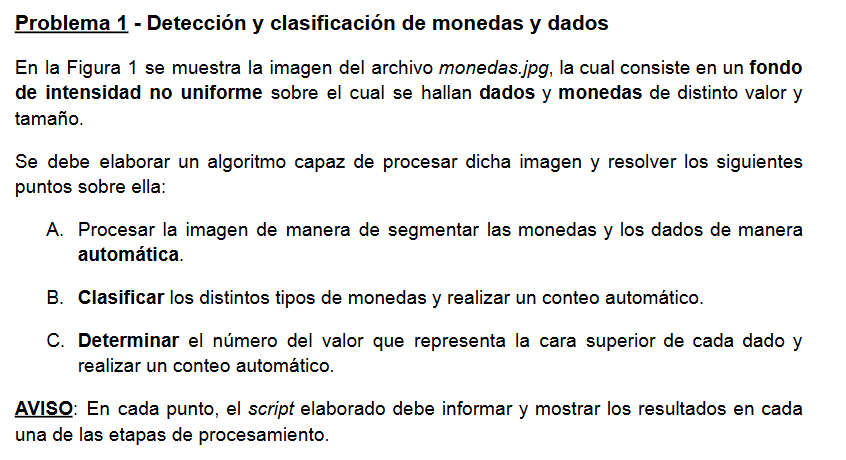

In [47]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import math

# PARTE A

In [48]:
img = cv2.imread('img/monedas.jpg')

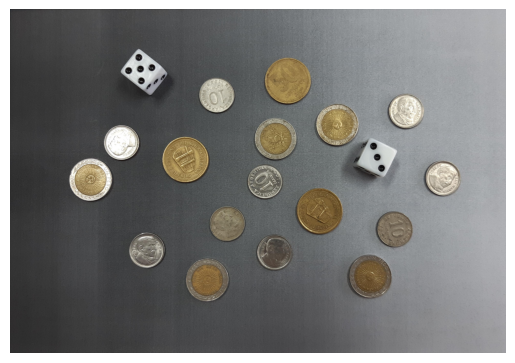

In [49]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [50]:
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

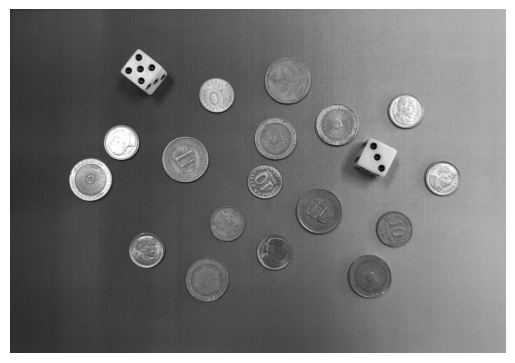

In [51]:
plt.imshow(img_gris, cmap='gray')
plt.axis('off')
plt.show()

In [52]:
# filtro gaussiano
img_gris_blur = cv2.GaussianBlur(img_gris, (9, 9), 2)

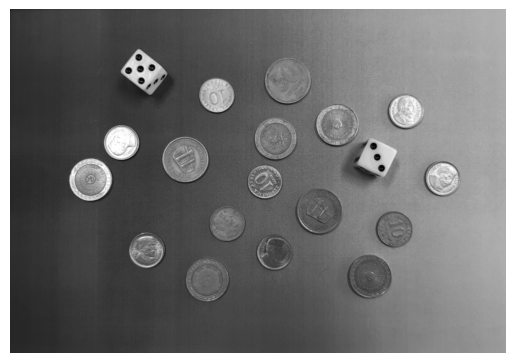

In [53]:
plt.imshow(img_gris_blur, cmap='gray')
plt.axis('off')
plt.show()

umbralado de la practica pdi_u3_segmentacion.py

con  cv2.threshold()

https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57

100.0
uint8
[  0 255]


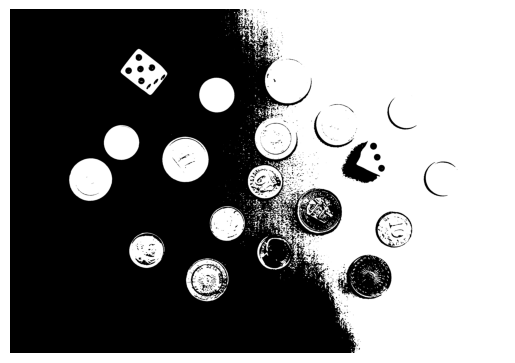

In [54]:
th_out, img_umbralado = cv2.threshold(img_gris_blur, thresh=100, maxval=255, type=cv2.THRESH_BINARY)
print(th_out)
print(img_umbralado.dtype)
print(np.unique(img_umbralado))
plt.imshow(img_umbralado, cmap='gray')
plt.axis('off')
plt.show()

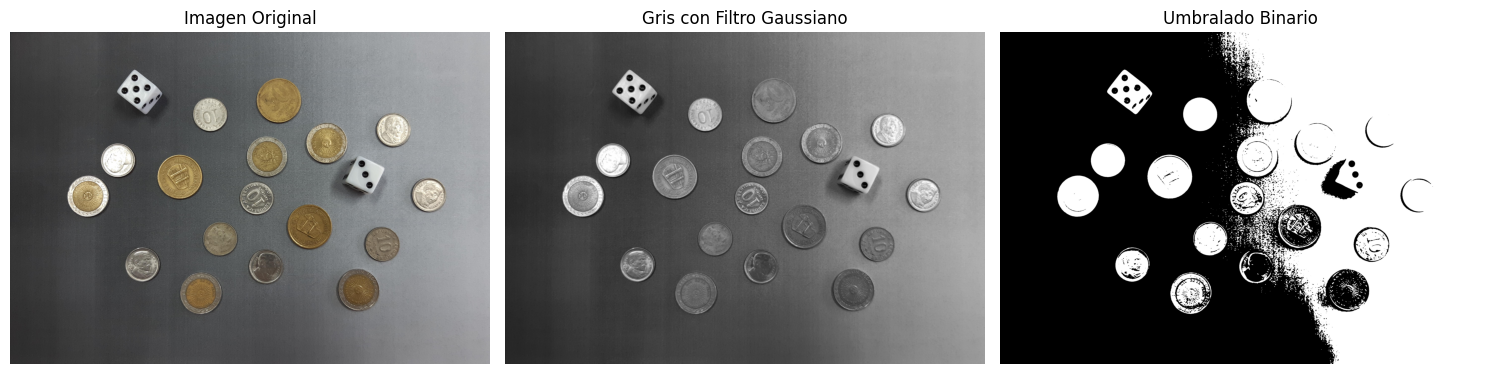

In [55]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gris_blur, cmap='gray')
plt.title('Gris con Filtro Gaussiano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_umbralado, cmap='gray')
plt.title('Umbralado Binario')
plt.axis('off')

plt.tight_layout()
plt.show()


 cv2.adaptiveThreshold(

   imagen_fuente (grises),

   valor_maximo (255, blanco),

   metodo_adaptativo (cv2.ADAPTIVE_THRESH_GAUSSIAN_C -> mejor para iluminación variable),

   tipo_umbral (cv2.THRESH_BINARY_INV -> Invertido, queremos objetos blancos),

   tamano_bloque (ej. 31x31 píxeles, debe ser impar),
   
   C (constante a restar de la media, ajusta la sensibilidad)
 )

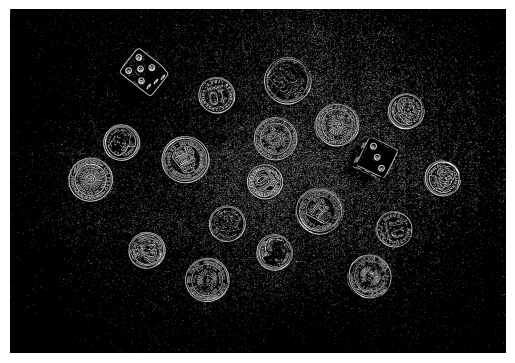

In [56]:
# hay que hacer umbralado local (vecinos)
img_umbralado_oscuro = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,   # objetos oscuros
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.axis('off')
plt.show()

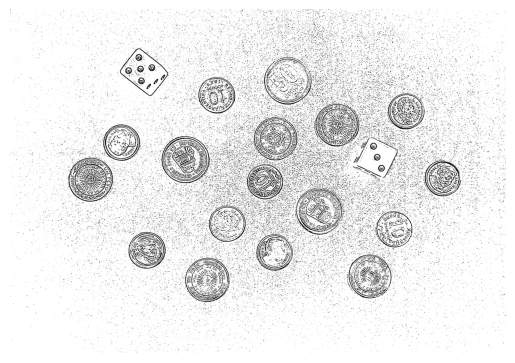

In [57]:
# hay que hacer umbralado local (vecinos)
img_umbralado_blancos = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,   # objetos blancos
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

plt.imshow(img_umbralado_blancos, cmap='gray')
plt.axis('off')
plt.show()

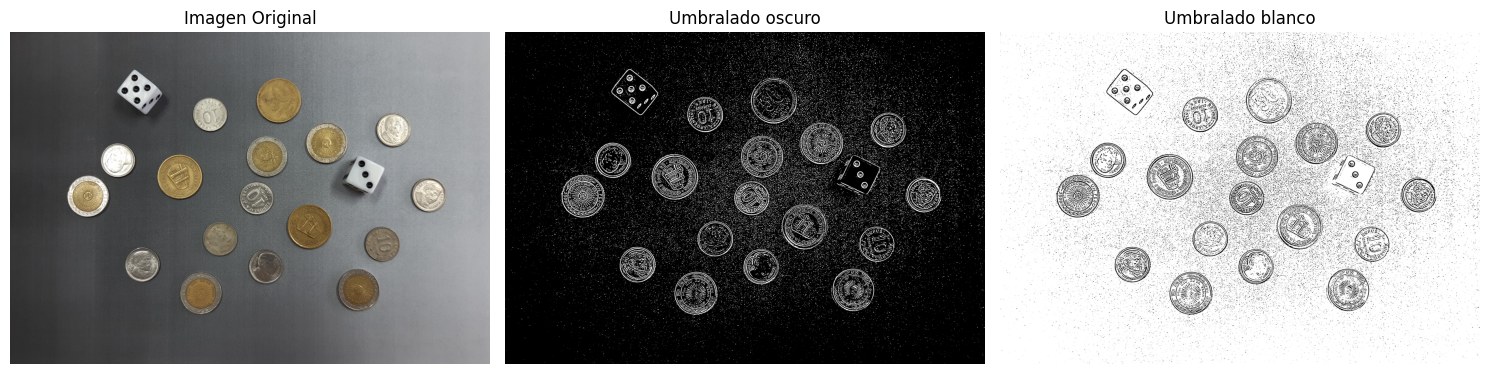

In [58]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.title('Umbralado oscuro')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Umbralado blanco')
plt.axis('off')

plt.tight_layout()
plt.show()

In [59]:
# componentes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    img_umbralado_blancos,
    connectivity=8,
    ltype=cv2.CV_32S
)
print(num_labels, labels, stats, centroids)
img_umbralado_blancos.shape

252 [[1 0 0 ... 2 2 2]
 [0 0 0 ... 2 2 2]
 [0 0 2 ... 2 2 2]
 ...
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]] [[      0       0    3871    2681  810303]
 [      0       0       1       1       1]
 [      0       0    3871    2681 9196179]
 ...
 [   1541    2245      36      16     238]
 [   1599    2245      13       7      30]
 [   2836    2246       1       1       1]] [[2070.73471529 1257.08243336]
 [   0.            0.        ]
 [1952.59443819 1354.86505722]
 [2489.            0.        ]
 [3222.           71.        ]
 [1121.           95.        ]
 [2158.           94.        ]
 [2480.          251.5       ]
 [1051.3208945   493.22502561]
 [2015.          340.        ]
 [3259.          353.        ]
 [1004.26161369  368.75550122]
 [ 997.85526316  379.88157895]
 [1010.14583333  381.94791667]
 [1020.23076923  384.92307692]
 [1002.28571429  392.92307692]
 [1111.55263158  446.85087719]
 [1021.79381443  460.64742268]
 [1088.96629213  454.12359551]
 [1099.57983193  461.00

(2681, 3871)

In [60]:
copia_img = img.copy()

In [61]:
def encontrar_figuras(imagen, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA):

    objetos_contados = 0 

    conteo_areas={}

    recortes_para_ensamblar = []

    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img_gris_blur = cv2.GaussianBlur(img_gris, (9, 9), 2)

    img_umbralado_blancos = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,   # objetos blancos
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

    (num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    img_umbralado_blancos,
    connectivity=8,
    ltype=cv2.CV_32S
)

    for i in range(1, num_labels-1):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]


        if AREA_MAXIMA_VALIDA > area >= AREA_MINIMA_VALIDA:

            #area_agrupada = int((area // 100.0)* 100) 
            area_agrupada = int(math.ceil(area / 100.0)) * 100

            if area_agrupada in conteo_areas:
                conteo_areas[area_agrupada] += 1
            
            else:
                conteo_areas[area_agrupada] = 1
    
            objetos_contados += 1 

            cv2.rectangle(imagen, (x, y), (x + w, y + h), (0, 255, 0), 2)

            (cX, cY) = centroids[i]
            cv2.putText(imagen, str(objetos_contados), (int(cX) - 10, int(cY)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            
            objeto_recortado = imagen[y:y + h, x:x + w]
            
            recortes_para_ensamblar.append(objeto_recortado)
            
            nombre_ventana = f"Objeto {objetos_contados} (Area: {area_agrupada})"
            cv2.imshow(nombre_ventana, objeto_recortado)

    imagen_ensamblada_recortes = None
    if recortes_para_ensamblar:
        recortes_por_fila = 5 
        max_h = max([r.shape[0] for r in recortes_para_ensamblar])
        
        filas_de_recortes = []
        fila_actual = []

        for idx, recorte in enumerate(recortes_para_ensamblar):
            # 1. PADDING vertical (a la altura máxima)
            padding_top = (max_h - recorte.shape[0]) // 2
            padding_bottom = max_h - recorte.shape[0] - padding_top
            recorte_padded = cv2.copyMakeBorder(recorte, padding_top, padding_bottom, 0, 0, 
                                                cv2.BORDER_CONSTANT, value=[0,0,0])
            
            fila_actual.append(recorte_padded)
            
            # Comprobar si es el final de una fila o el último elemento
            if (idx + 1) % recortes_por_fila == 0 or (idx + 1) == len(recortes_para_ensamblar):
                filas_de_recortes.append(np.hstack(fila_actual)) # Ensamblaje horizontal
                fila_actual = []

        # --- CORRECCIÓN: Alineación de Anchos de Filas para np.vstack ---
        
        # 2. Determinar el ancho máximo (ancho de la primera fila)
        max_width_fila = filas_de_recortes[0].shape[1]
        
        if len(filas_de_recortes) > 1:
            # 3. Rellenar (padding horizontal) la última fila si es necesario
            ultima_fila_idx = len(filas_de_recortes) - 1
            ultima_fila = filas_de_recortes[ultima_fila_idx]
            
            if ultima_fila.shape[1] < max_width_fila:
                padding_right = max_width_fila - ultima_fila.shape[1]
                
                # Aplicar padding a la derecha para igualar el ancho
                ultima_fila_padded = cv2.copyMakeBorder(ultima_fila, 0, 0, 0, padding_right, 
                                                        cv2.BORDER_CONSTANT, value=[0,0,0])
                
                # Reemplazar la última fila
                filas_de_recortes[ultima_fila_idx] = ultima_fila_padded

        # 4. Concatenar todas las filas verticalmente
        imagen_ensamblada_recortes = np.vstack(filas_de_recortes)

    else:
        # Imagen de mensaje si no se encuentran figuras
        imagen_ensamblada_recortes = np.zeros((100, 400, 3), dtype=np.uint8)
        cv2.putText(imagen_ensamblada_recortes, "No se encontraron recortes validos", (10, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return imagen, objetos_contados, conteo_areas_similares, imagen_ensamblada_recortes
  
imagen_con_dibujos, total_objetos, conteo_areas, imagen_mosaico = encontrar_figuras(copia_img, 100, 5000)

# Área mínima: 500, Área máxima: 3000 (para ignorar el Objeto 3 pequeño)


# El bloque de visualización que proporcionaste
plt.figure(figsize=(18, 8))

# 1. Imagen Original con Detecciones
plt.subplot(1, 2, 1) 
plt.imshow(cv2.cvtColor(imagen_con_dibujos, cv2.COLOR_BGR2RGB))
plt.title(f'1. Objetos Detectados (Total: {total_objetos})')
plt.axis('off')

# 2. Mosaico de Recortes
plt.subplot(1, 2, 2) 
plt.imshow(cv2.cvtColor(imagen_mosaico, cv2.COLOR_BGR2RGB))
plt.title('2. Mosaico de Recortes Ensamblados')
plt.axis('off')

plt.tight_layout()
plt.show()

# print("\nResumen de Conteo de Áreas Similares:", conteo_areas)
#encontrar_figuras(copia_img, 250, 350)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 125 and the array at index 1 has size 138

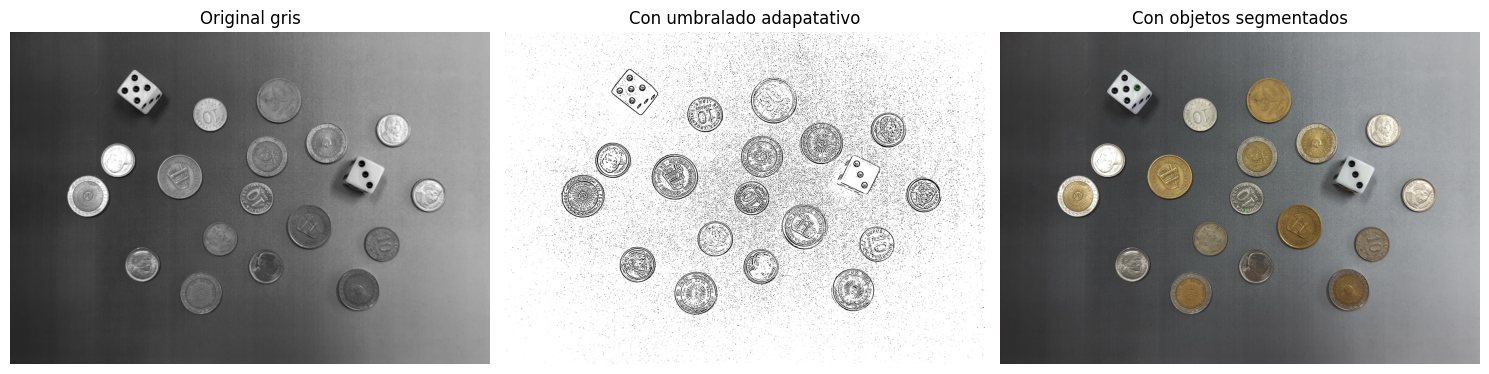

In [ ]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(img_gris_blur, cmap='gray')
plt.title('Original gris')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Con umbralado adapatativo')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(copia_img, cv2.COLOR_BGR2RGB))
plt.title('Con objetos segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
img_gris = cv2.cvtColor(copia_img, cv2.COLOR_BGR2GRAY)

_, img_binaria = cv2.threshold(img_gris, 127, 255, cv2.THRESH_BINARY) 

contours, hierarchy = cv2.findContours(img_binaria, cv2.RETR_LIST, cv2.RETR_EXTERNAL)
